**Bài 1**

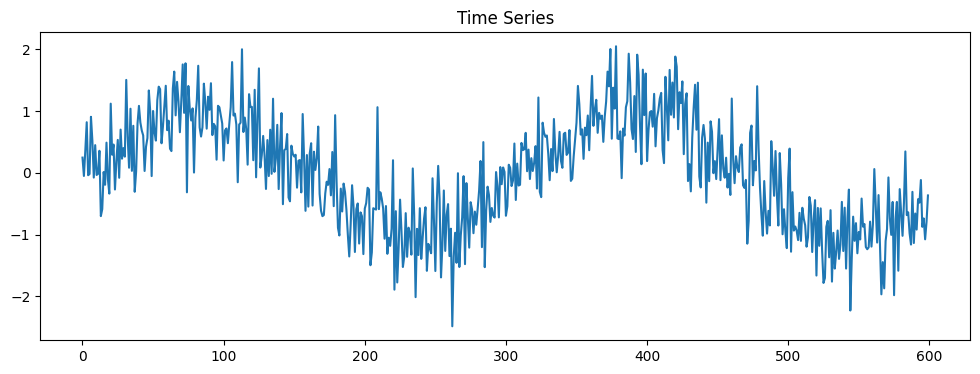

In [17]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

np.random.seed(42)

time = np.arange(0, 600)

data = np.sin(0.02 * time) + 0.5 * np.random.randn(600)
plt.figure(figsize=(12,4))
plt.plot(data)
plt.title("Time Series")
plt.show()

In [18]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data.reshape(-1,1))

In [19]:
def create_sequences(data, seq_length):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

seq_length = 20

X, y = create_sequences(data_scaled, seq_length)

print(X.shape)
print(y.shape)

(580, 20, 1)
(580, 1)


In [20]:
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

In [21]:
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

In [22]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=32
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32
)

In [23]:
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, h_n = self.rnn(x)

        out = out[:, -1, :]
        out = self.fc(out)

        return out

In [24]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):

        out, (h_n, c_n) = self.lstm(x)

        out = out[:, -1, :]
        out = self.fc(out)

        return out

In [25]:
rnn_model = RNNModel()
lstm_model = LSTMModel()

In [26]:
criterion = nn.MSELoss()

rnn_optimizer = torch.optim.Adam(
    rnn_model.parameters(),
    lr=1e-3
)

lstm_optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=1e-3
)

In [27]:
def train_model(model, optimizer, epochs=100):

    train_losses = []

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        train_losses.append(avg_loss)

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

    return train_losses

In [28]:
print("Training RNN...")
rnn_losses = train_model(rnn_model, rnn_optimizer)

print("\nTraining LSTM...")
lstm_losses = train_model(lstm_model, lstm_optimizer)

Training RNN...
Epoch 10/100, Loss: 0.012872
Epoch 20/100, Loss: 0.012715
Epoch 30/100, Loss: 0.012803
Epoch 40/100, Loss: 0.012855
Epoch 50/100, Loss: 0.012639
Epoch 60/100, Loss: 0.012503
Epoch 70/100, Loss: 0.012485
Epoch 80/100, Loss: 0.012974
Epoch 90/100, Loss: 0.012447
Epoch 100/100, Loss: 0.012780

Training LSTM...
Epoch 10/100, Loss: 0.019723
Epoch 20/100, Loss: 0.012827
Epoch 30/100, Loss: 0.014299
Epoch 40/100, Loss: 0.012572
Epoch 50/100, Loss: 0.012608
Epoch 60/100, Loss: 0.012657
Epoch 70/100, Loss: 0.012557
Epoch 80/100, Loss: 0.012974
Epoch 90/100, Loss: 0.012997
Epoch 100/100, Loss: 0.012523


In [29]:
def evaluate(model):

    model.eval()

    predictions = []

    actuals = []

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            outputs = model(X_batch)

            predictions.extend(outputs.numpy())
            actuals.extend(y_batch.numpy())

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    mse = mean_squared_error(actuals, predictions)

    return mse, predictions, actuals

In [30]:
rnn_mse, rnn_pred, actual = evaluate(rnn_model)

lstm_mse, lstm_pred, actual = evaluate(lstm_model)

print("RNN MSE :", rnn_mse)
print("LSTM MSE:", lstm_mse)

RNN MSE : 0.012901599518954754
LSTM MSE: 0.01146541628986597


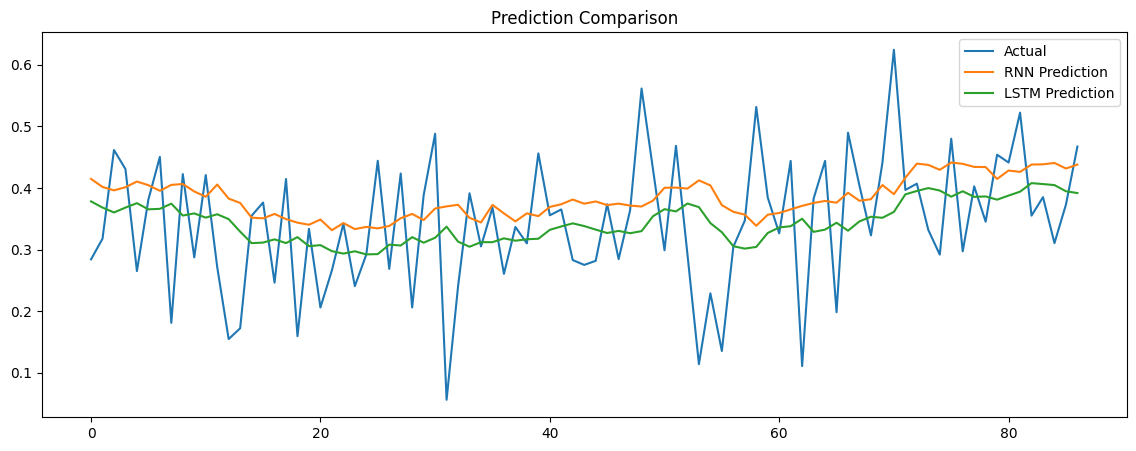

In [31]:
plt.figure(figsize=(14,5))

plt.plot(actual, label="Actual")

plt.plot(rnn_pred, label="RNN Prediction")

plt.plot(lstm_pred, label="LSTM Prediction")

plt.legend()

plt.title("Prediction Comparison")

plt.show()

LSTM cho kết quả tốt hơn RNN cơ bản vì:
- MSE thấp hơn
- Đường dự đoán mượt hơn
- Giảm hiện tượng mất gradient
- Ghi nhớ phụ thuộc dài hạn tốt hơn

**Bài 2**